In [14]:
from lips import get_root_path
from lips.benchmark.airfransBenchmark import AirfRANSBenchmark
from lips.dataset.airfransDataSet import download_data
import os
from pathlib import Path
import numpy as np
import torch
from collections import Counter

In [2]:
LIPS_PATH = get_root_path()
LOG_PATH = LIPS_PATH + "lips_logs.log"
BENCHMARK_NAME = "DEFAULT"

BASE_DIR = Path.cwd().parent
DIRECTORY_NAME = os.path.join(BASE_DIR, 'airfrans_data/Dataset')
BENCH_CONFIG_PATH = os.path.join(BASE_DIR, 'src/confAirfoil.ini')

print(BASE_DIR)
print(BENCH_CONFIG_PATH)

/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution
/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution/src/confAirfoil.ini


## AirfRANS Data Playground

In [3]:
# Load all datasets
benchmark=AirfRANSBenchmark(benchmark_path = DIRECTORY_NAME,
                            config_path = BENCH_CONFIG_PATH,
                            benchmark_name = BENCHMARK_NAME,
                            log_path = LOG_PATH)
print(vars(benchmark))
benchmark.load(path=DIRECTORY_NAME)

{'benchmark_name': 'DEFAULT', 'benchmark_path': '/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution/airfrans_data/Dataset', 'path_datasets': '/Users/jay/Desktop/MIT/DIG/ob-gnn_code/ML4CFD-Offset-based-Graph-Convolution/airfrans_data/Dataset/DEFAULT', 'config': <lips.config.configmanager.ConfigManager object at 0x29213bbe0>, 'dataset': None, 'observations': {}, 'predictions': {}, 'augmented_simulator': None, 'log_path': '/opt/anaconda3/envs/ob-gnn/lib/python3.10/site-packages/lips/lips_logs.log', 'logger': <Logger Benchmark (INFO)>, 'is_loaded': False, 'evaluation': <lips.evaluation.airfrans_evaluation.AirfRANSEvaluation object at 0x29213bdc0>, 'training_simulator': None, 'test_simulator': None, 'train_dataset': <lips.dataset.airfransDataSet.AirfRANSDataSet object at 0x2921cc1f0>, '_test_dataset': <lips.dataset.airfransDataSet.AirfRANSDataSet object at 0x29213bc10>, '_test_ood_dataset': <lips.dataset.airfransDataSet.AirfRANSDataSet object at 0x2921cc310>, 'ml_n

Loading dataset (task: reynolds, split: test): 100%|██████████| 496/496 [01:13<00:00,  6.77it/s]


### Exploring Dataset Attributes

In [4]:
train_dataset = benchmark.train_dataset
print(vars(train_dataset).keys())
print(train_dataset._size_x)
print(train_dataset._sizes_x)
print(train_dataset._attr_x)
print(train_dataset.no_normalization_attr_x)
# print(vars(train_dataset))

dict_keys(['name', 'data', 'size', 'current_index', '_task', '_split', '_attr_names', 'extra_data', 'logger', 'config', '_size_x', '_size_y', '_sizes_x', '_sizes_y', '_attr_x', '_attr_y', 'no_normalization_attr_x'])
7
[1 1 1 1 1 1 1]
('x-position', 'y-position', 'x-inlet_velocity', 'y-inlet_velocity', 'distance_function', 'x-normals', 'y-normals')
['x-normals', 'y-normals']


In [5]:
print(type(train_dataset.data))
print(train_dataset.data.keys())
for k,v in train_dataset.data.items():
    print("key:", k, "\t\t size:",v.shape)

<class 'dict'>
dict_keys(['x-position', 'y-position', 'x-inlet_velocity', 'y-inlet_velocity', 'distance_function', 'x-normals', 'y-normals', 'x-velocity', 'y-velocity', 'pressure', 'turbulent_viscosity'])
key: x-position 		 size: (18515415,)
key: y-position 		 size: (18515415,)
key: x-inlet_velocity 		 size: (18515415,)
key: y-inlet_velocity 		 size: (18515415,)
key: distance_function 		 size: (18515415,)
key: x-normals 		 size: (18515415,)
key: y-normals 		 size: (18515415,)
key: x-velocity 		 size: (18515415,)
key: y-velocity 		 size: (18515415,)
key: pressure 		 size: (18515415,)
key: turbulent_viscosity 		 size: (18515415,)


### Load Test, Test & Test OOD Datasets
Print the Reynolds Range and AoA Range for each dataset split.

In [9]:
def print_dataset_details(dataset):
    simulation_names = dataset.extra_data['simulation_names']
    print("simulation_names shape:", simulation_names.shape)
    print("5 sample simulation names:\n", simulation_names[:5,:])
    all_reynolds = np.array([float(name.split('_')[2])/1.56e-5 for name,numID in simulation_names])
    all_aoa = np.array([float(name.split('_')[3]) for name,numID in simulation_names])
    print()
    print("reynolds range:", all_reynolds.min(), ",", all_reynolds.max())
    print("aoa range:", all_aoa.min(), ",",all_aoa.max() )
print("-- Train Dataset --")
train_dataset = benchmark.train_dataset
print_dataset_details(train_dataset)

-- Train Dataset --
simulation_names shape: (103, 2)
5 sample simulation names:
 [['airFoil2D_SST_58.831_-3.563_2.815_4.916_10.078' '170180']
 ['airFoil2D_SST_67.481_-1.259_5.136_2.438_18.882' '179653']
 ['airFoil2D_SST_56.177_2.108_1.208_3.592_0.0_14.763' '184381']
 ['airFoil2D_SST_56.749_1.468_1.967_7.293_1.0_8.866' '177944']
 ['airFoil2D_SST_71.85_7.865_2.88_6.646_0.0_18.137' '178145']]

reynolds range: 3007692.307692308 , 4977051.282051282
aoa range: -4.79 , 14.35


In [10]:
# Test Dataset
test_dataset = benchmark._test_dataset
print("-- Test Dataset --")
print_dataset_details(test_dataset)
print()
# Test OOD Dataset
ood_dataset = benchmark._test_ood_dataset
print("-- Test OOD Dataset --")
print_dataset_details(ood_dataset)

-- Test Dataset --
simulation_names shape: (200, 2)
5 sample simulation names:
 [['airFoil2D_SST_31.812_1.334_0.371_3.287_0.0_19.548' '179033']
 ['airFoil2D_SST_39.741_14.642_3.175_3.316_1.0_10.583' '197146']
 ['airFoil2D_SST_85.752_6.341_0.382_6.715_8.448' '180238']
 ['airFoil2D_SST_80.247_1.078_1.298_5.983_0.0_5.593' '181491']
 ['airFoil2D_SST_61.728_9.994_3.311_7.957_1.0_7.685' '172620']]

reynolds range: 2039230.7692307692 , 5975192.307692307
aoa range: -4.94 , 14.686

-- Test OOD Dataset --
simulation_names shape: (496, 2)
5 sample simulation names:
 [['airFoil2D_SST_36.622_11.319_3.941_5.424_1.0_16.283' '181794']
 ['airFoil2D_SST_43.327_8.905_4.236_6.511_10.744' '163156']
 ['airFoil2D_SST_89.151_4.462_0.974_4.094_1.0_19.856' '180991']
 ['airFoil2D_SST_87.422_2.992_1.895_3.128_1.0_10.656' '189773']
 ['airFoil2D_SST_42.531_-3.927_1.264_6.838_0.0_7.489' '180542']]

reynolds range: 2005320.512820513 , 5999487.17948718
aoa range: -4.94 , 14.926


### Answering AirfRANS Dataset Questions

In [12]:
# Q: Is the distance_function signed or not?
# A: No
dist = train_dataset.data['distance_function']
print(dist)
print(dist.shape)
print("min dist value:", np.min(dist), "\tmax dist value:",np.max(dist)) # min distance is 0 => unsigned

[3.2230763  3.22309656 2.99761127 ... 2.63089053 2.63520512 2.63947669]
(18515415,)
min dist value: 0.0 	max dist value: 3.6047437730261156


In [15]:
# Q: How many airfoil node are there across different samples? (in test dataset)
num_airfoil_nodes = []
p = 0
for sim_name, num_nodes in test_dataset.extra_data['simulation_names']:
    num_nodes = int(num_nodes)
    x_normals = test_dataset.data['x-normals'][p:p+num_nodes]
    num_airfoil_nodes.append(np.where(x_normals!=0)[0].shape[0])
    p += num_nodes

print("frequency of each number of airfoil nodes across samples:")
print((Counter(num_airfoil_nodes)))
print("min",min(num_airfoil_nodes), "max",max(num_airfoil_nodes))

frequency of each number of airfoil nodes across samples:
Counter({1018: 8, 1020: 6, 1019: 6, 1007: 5, 1012: 5, 1003: 5, 1014: 5, 1011: 4, 1029: 4, 1028: 4, 1032: 4, 1015: 4, 1022: 3, 978: 3, 1005: 3, 1021: 3, 1026: 3, 1013: 3, 1024: 3, 1038: 3, 1010: 3, 1051: 3, 1027: 3, 958: 3, 1017: 3, 962: 2, 989: 2, 1043: 2, 1009: 2, 902: 2, 946: 2, 992: 2, 1016: 2, 980: 2, 1090: 2, 1033: 2, 995: 2, 997: 2, 1037: 2, 996: 2, 1114: 2, 1034: 2, 1035: 2, 880: 2, 1128: 1, 1036: 1, 1059: 1, 961: 1, 901: 1, 915: 1, 1006: 1, 981: 1, 1002: 1, 979: 1, 1054: 1, 937: 1, 924: 1, 1025: 1, 1099: 1, 1001: 1, 908: 1, 1030: 1, 1065: 1, 1045: 1, 923: 1, 975: 1, 1119: 1, 1008: 1, 1084: 1, 1094: 1, 1042: 1, 1023: 1, 1165: 1, 886: 1, 1089: 1, 971: 1, 894: 1, 909: 1, 1061: 1, 952: 1, 931: 1, 858: 1, 1048: 1, 1060: 1, 1091: 1, 1056: 1, 887: 1, 1066: 1, 963: 1, 912: 1, 942: 1, 976: 1, 994: 1, 941: 1, 1046: 1, 1078: 1, 944: 1, 861: 1, 966: 1, 1053: 1, 862: 1, 945: 1, 1087: 1, 984: 1, 1077: 1, 907: 1, 970: 1})
min 858 max 1

In [20]:
# Q: Are inlet velocities are the same across all nodes?
# A: Yes
# Q: Do inlet velocities match filename free-stream velocity + AoA?
# A: Yes
sim0, num_nodes = train_dataset.extra_data['simulation_names'][0] # first sample of train dataset
num_nodes = int(num_nodes)
x_inlets = train_dataset.data['x-inlet_velocity'][:num_nodes]
y_inlets = train_dataset.data['y-inlet_velocity'][:num_nodes]
print("Simulation Name:",sim0, "\nNum Nodes:",num_nodes)
print("Frequency of x and y inlet velocities across all nodes:")
print(Counter(x_inlets))
print(Counter(y_inlets))

Simulation Name: airFoil2D_SST_58.831_-3.563_2.815_4.916_10.078 
Num Nodes: 170180
Frequency of x and y inlet velocities across all nodes:
Counter({58.71728371719323: 170180})
Counter({-3.656111852040976: 170180})


In [ ]:
# Q: What are the mesh x,y positions across all samples in the dataset?
def explore_mesh_dimensions(dataset):
    mesh_dim = []
    p = 0
    for sim_name, num_nodes in dataset.extra_data['simulation_names']:
        num_nodes = int(num_nodes)
        x = dataset.data['x-position'][p:p+num_nodes]
        y = dataset.data['y-position'][p:p+num_nodes]
        mesh_dim.append([np.min(x), np.max(x), np.min(y), np.max(y)])
        p += num_nodes
    print("num samples:", len(mesh_dim))
    mesh_dim = np.array(mesh_dim)
    print("min x", np.min(mesh_dim[:,0]), np.max(mesh_dim[:,0]))
    print("max x", np.min(mesh_dim[:,1]), np.max(mesh_dim[:,1]))
    print("min y", np.min(mesh_dim[:,2]), np.max(mesh_dim[:,2]))
    print("max y", np.min(mesh_dim[:,3]), np.max(mesh_dim[:,3]))

print("Train Dataset")
explore_mesh_dimensions(train_dataset)
print("\nTest Dataset")
explore_mesh_dimensions(test_dataset)

Train Dataset
num samples: 103
min x -2.164407253265381 -2.155540943145752
max x 4.225321292877197 4.231393814086914
min y -1.6455789804458618 -1.6138968467712402
max y 1.6129454374313354 1.6210976839065552

Test Dataset
num samples: 200
min x -2.164767265319824 -2.155000925064087
max x 4.225302219390869 4.231489658355713
min y -1.643295168876648 -1.613545298576355
max y 1.6133023500442505 1.6211119890213013


## Saving Specific Sample

In [26]:
target_sim_name = 'airFoil2D_SST_46.385_3.538_4.58_2.02_19.22'
test_dataset = benchmark._test_dataset

# Find target simulation in the dataset split
p = 0
p_end = 0
for i, (sim_name, num_nodes) in enumerate(test_dataset.extra_data['simulation_names']):
    num_nodes = int(num_nodes)
    if sim_name == target_sim_name:
        print("found simulation:", target_sim_name)
        p_end = p+num_nodes
        break
    p += num_nodes

found simulation: airFoil2D_SST_46.385_3.538_4.58_2.02_19.22


In [27]:
# Construct input npy file
out = []
out.append(test_dataset.data['x-position'][p:p_end])
out.append(test_dataset.data['y-position'][p:p_end])
out.append(test_dataset.data['x-inlet_velocity'][p:p_end])
out.append(test_dataset.data['y-inlet_velocity'][p:p_end])
out.append(test_dataset.data['distance_function'][p:p_end])
out.append(test_dataset.data['x-normals'][p:p_end])
out.append(test_dataset.data['y-normals'][p:p_end])
out.append(test_dataset.extra_data['surface'][p:p_end])
for feature in out:
    print(feature.shape)

(181011,)
(181011,)
(181011,)
(181011,)
(181011,)
(181011,)
(181011,)
(181011,)


In [28]:
# Get Edges for input npy file
import vtkmodules
path_to_simulations = DIRECTORY_NAME
path = os.path.join(path_to_simulations, target_sim_name, target_sim_name+"_internal.vtu")
reader = vtkmodules.vtkIOXML.vtkXMLUnstructuredGridReader()
reader.SetFileName(path)
reader.Update()
unstructured_grid = reader.GetOutput()
cells = unstructured_grid.GetCells().GetData()
cells = vtkmodules.util.numpy_support.vtk_to_numpy(cells).reshape(-1, 5)
cells[:, 0] = cells[: , 4]
srcs = torch.tensor(cells[:, :4].flatten())
dsts = torch.tensor(cells[:, 1:].flatten())
print(srcs.shape)
print(dsts.shape)
edges = np.stack([srcs,dsts], axis=1)
print(edges.shape)
out.append(edges)

torch.Size([718988])
torch.Size([718988])
(718988, 2)


In [ ]:
# Convert to object array
obj_array = np.array(out, dtype=object)
# Save file
np.save("og_obgnn_test.npy", obj_array)

In [ ]:
# Save Targets for Specific Sample
targets = []
targets.append(test_dataset.data['x-velocity'][p:p+p_end])
targets.append(test_dataset.data['y-velocity'][p:p+p_end])
targets.append(test_dataset.data['pressure'][p:p+p_end])
targets.append(test_dataset.data['turbulent_viscosity'][p:p+p_end])
targets = np.stack(targets,axis=1)
print(targets.shape)
np.save("targets_og_obgnn_test.npy", targets)

(181011, 4)


## Visualizing Airfoil

In [51]:
import matplotlib.pyplot as plt
def visualize_airfoil(x,y,is_surface,crop=False,airfoil_only=False):
    colors = np.where(is_surface == 0, 'b', 'r')
    sizes = np.where(is_surface == 0, 0.5, 10)
    plt.title(f"Airfoil Visualization")
    plt.xlabel("x")
    plt.ylabel("y")
    if airfoil_only:
        airfoil_indices = np.where(is_surface == 1)[0]
        x = x[airfoil_indices]
        y = y[airfoil_indices]
        colors = colors[airfoil_indices]
        sizes = 0.5
    plt.scatter(x, y, s=sizes, c=colors)
    if crop:
        plt.xlim(-0.05,1.05)
        plt.ylim(-0.3,0.3)
    plt.show()

0 airFoil2D_SST_58.831_-3.563_2.815_4.916_10.078 170180
num airfoil nodes (944,)
num non-airfoil nodes (169236,)


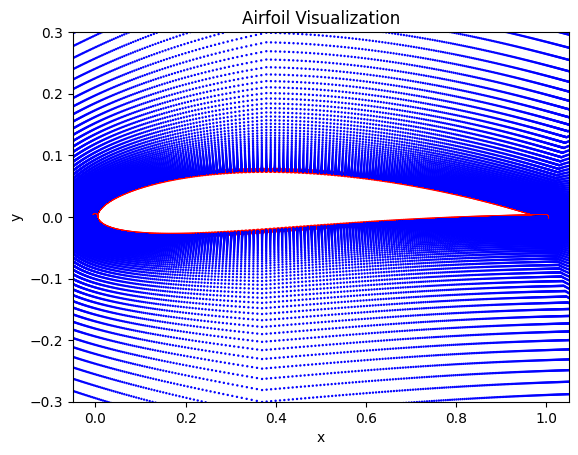

In [ ]:
target_i = 0
p = 0
x,y,is_surface = None, None, None
sample_file,sample_size = '',''

for i in range(target_i+1):
    sample_file,sample_size = train_dataset.extra_data['simulation_names'][i]
    sample_size = int(sample_size)
    x = train_dataset.data['x-position'][p:p+sample_size]
    y = train_dataset.data['y-position'][p:p+sample_size]
    is_surface = train_dataset.extra_data['surface'][p:p+sample_size]
    p += sample_size

print(target_i, sample_file, sample_size)

print("num airfoil nodes", np.where(is_surface!=0)[0].shape)
print("num non-airfoil nodes", np.where(is_surface==0)[0].shape)
visualize_airfoil(x,y,is_surface,crop=True,airfoil_only=False)

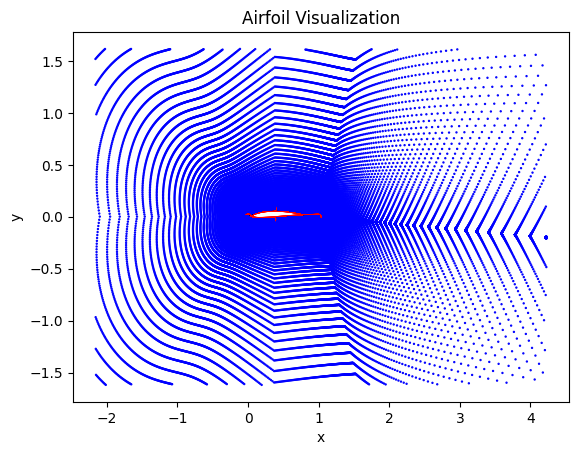

In [23]:
visualize_airfoil(x,y,is_surface,crop=False,airfoil_only=False)

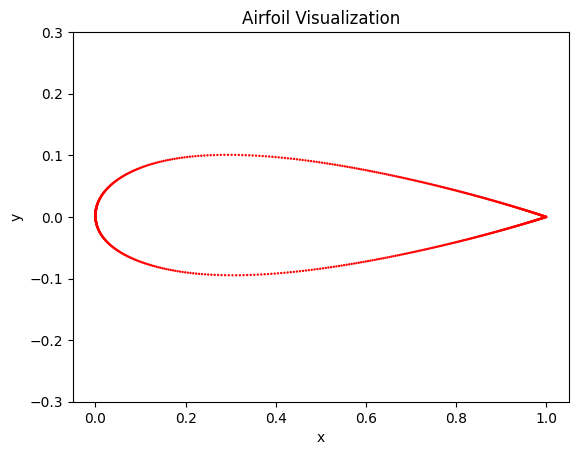

In [54]:
visualize_airfoil(x,y,is_surface,crop=True,airfoil_only=True)